# <span style="color: green;"> SALES .</span>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import pickle
import matplotlib.dates as mdates

### <span style="color: green;"> Leemos el Dataset .</span>

In [39]:
df= pd.read_csv("../data/raw/sales.csv")
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [40]:
df.shape

(366, 2)

In [41]:
df.dtypes

date      object
sales    float64
dtype: object

In [42]:
df.isnull().sum() #faltantes

date     0
sales    0
dtype: int64

In [43]:
df.duplicated().sum() #duplicados

np.int64(0)

In [44]:
df.nunique() #valores unicos

date     366
sales    366
dtype: int64

### <span style="color: green;"> Construye y analiza la serie temporal.</span>

Tengo que transformar mis datos en una estructura que tenga dos cosas clave:

Índice temporal: una columna o índice con fechas o tiempos ordenados.

Valores numéricos: una o más columnas con los valores que evolucionan con el tiempo en este caso tengo que convertir date , ya que como bien se visualiza es Object

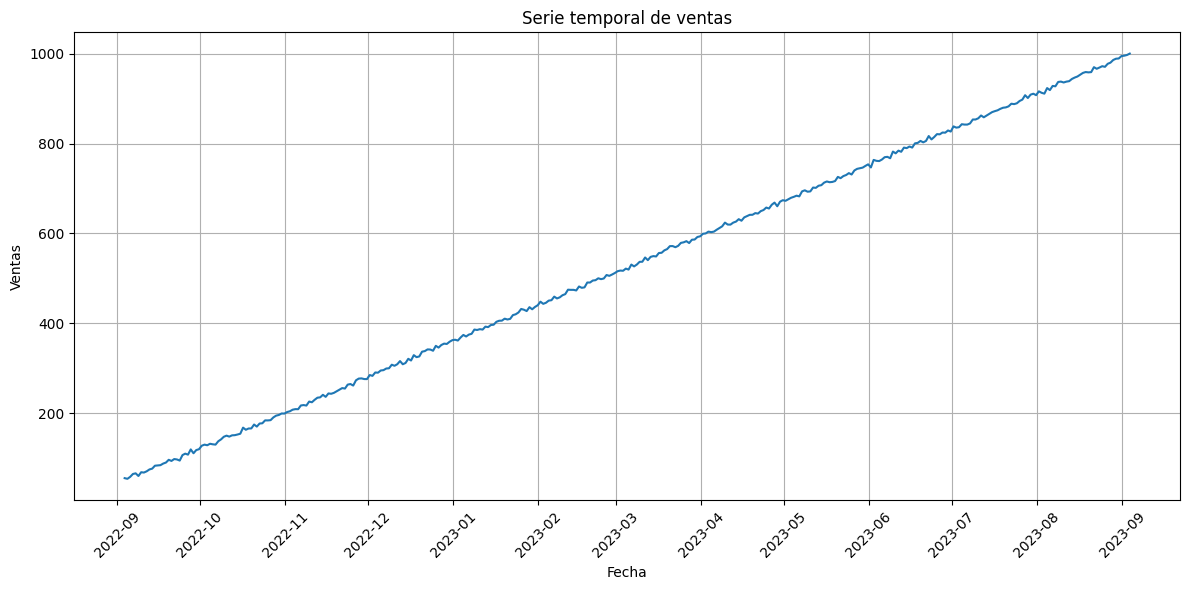

In [45]:
# Convertir la columna 'date' a tipo datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date') # Ordenar por fecha (opcional pero recomendable)
df.set_index('date', inplace=True) # Establecer 'date' como índice

# Graficar la serie temporal
plt.figure(figsize=(12, 6))
plt.plot(df['sales'])
plt.title('Serie temporal de ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)

# Mejora del formato del eje x
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



### <span style="color: green;">¿ Cual es el tensor de la serie temporal.</span>

En el contexto de series temporales con pandas, el "tensor" se refiere a la estructura de datos que almacena la información de la serie. En este caso, después de transformar mi DataFrame, el tensor de la serie temporal es un **DataFrame de pandas** (o un **Series** si solo tienes una columna de valores), donde:

- El índice es de tipo `DatetimeIndex` (las fechas).
- Las columnas contienen los valores numéricos que evolucionan en el tiempo (por ejemplo, `sales`).

In [ ]:
sales_tensor = df['sales'].values

In [49]:
print(sales_tensor.shape)  # ejemplo: (365,)


(366,)


### <span style="color: green;">¿ Cual es la tendencia?.</span>

La **tendencia** en una serie temporal es el comportamiento general de los datos a lo largo del tiempo, es decir, si los valores tienden a aumentar, disminuir o mantenerse estables.

Para identificar la tendencia en mi serie de ventas, vuelvo a observar la gráfica que genere con:

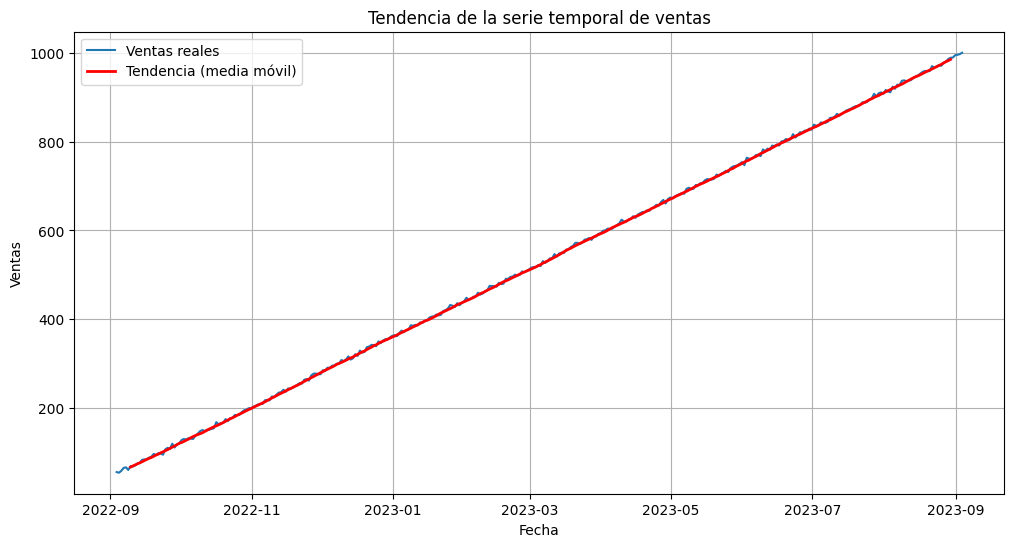

In [50]:
df['tendencia'] = df['sales'].rolling(window=12, center=True).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['sales'], label='Ventas reales')
plt.plot(df['tendencia'], label='Tendencia (media móvil)', linewidth=2, color='red')
plt.title('Tendencia de la serie temporal de ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


### CONCLUSION : 
> Línea azul: df['sales'] — Ventas reales
Representa los valores originales de ventas en cada periodo (día, mes, etc.).
>
> Puede haber mucho "ruido": subidas y bajadas bruscas debidas a estacionalidad, promociones, cambios del mercado, etc.

> Línea roja: df['tendencia'] — Media móvil centrada
Calcula el promedio de las ventas en una ventana de 12 períodos alrededor de cada punto (6 antes y 6 después), suavizando los picos.
>
> El parámetro center=True hace que el valor promedio se coloque en el centro de la ventana, para una representación más simétrica.
> 
> ¿Qué me permite ver esta media móvil?
Reduce la variabilidad local (ruido), permitiéndote observar la tendencia general.
>
> Es útil para ver si la serie crece, decrece o se mantiene estable en el tiempo.
>
> Permite detectar puntos de inflexión: momentos en los que la tendencia cambia de dirección.



Si la línea general sube con el tiempo, hay una **tendencia creciente**.  
Si baja, hay una **tendencia decreciente**.  
Si se mantiene estable, **no hay tendencia clara**.

### <span style="color: green;">¿ Es estacionaria ?.</span>

No, **no es estacionaria**.

Una serie temporal es **estacionaria** si sus propiedades estadísticas (media, varianza) no cambian a lo largo del tiempo, es decir, si no tiene tendencia ni estacionalidad marcada.

En este caso, tal y como se observa en la gráfica, la tendencia es **creciente** (los valores aumentan con el tiempo).  
Esto significa que la media de la serie cambia, por lo tanto **no es estacionaria**.

Vamos a comprobarlo formalmente, usaré la prueba de Dickey-Fuller aumentada (`adfuller`) de `statsmodels`:



In [52]:
resultado = adfuller(df['sales'].dropna())
print('p-value:', resultado[1])
if resultado[1] < 0.05:
    print("La serie es estacionaria")
else:
    print("La serie NO es estacionaria")

p-value: 0.9861899815311064
La serie NO es estacionaria


### <span style="color: green;">¿ Existe variabilidad o presencia de ruido ?.</span>

Sí, **existe variabilidad y presencia de ruido** en la serie temporal.

En cualquier serie temporal real, los valores no siguen una línea perfectamente recta, sino que presentan fluctuaciones alrededor de la tendencia general. Estas fluctuaciones se deben a factores aleatorios, cambios inesperados o eventos externos, y a esto se le llama **ruido**.

La **variabilidad** se observa en cómo los valores de ventas suben y bajan en diferentes momentos, incluso si la tendencia general es creciente.  
El **ruido** es esa parte impredecible y aleatoria de la serie que no sigue un patrón claro.

En mi gráfico, vemos que los puntos de ventas no están alineados perfectamente, sino que hay subidas y bajadas a lo largo del tiempo. Eso es variabilidad y ruido.

## <span style="color: green;"> Entrena un Arima .</span>

In [53]:
# Entrenar el modelo ARIMA (ajusta los parámetros p, d, q según tu análisis)
modelo = ARIMA(df['sales'], order=(2,1,2))
resultado = modelo.fit()

# Resumen del modelo
print(resultado.summary())

# Pronóstico para los próximos 10 periodos
prediccion = resultado.forecast(steps=10)
print(prediccion)

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-i

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  366
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -922.473
Date:                Tue, 29 Jul 2025   AIC                           1854.947
Time:                        16:36:45   BIC                           1874.446
Sample:                    09-03-2022   HQIC                          1862.696
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9013      0.025     36.658      0.000       0.853       0.949
ar.L2          0.0987      0.025      4.015      0.000       0.051       0.147
ma.L1         -1.9162      0.023    -82.739      0.0

- El modelo corre bien.

- El componente AR(1) es muy fuerte y significativo.

- La distribución de los residuos parece razonable (normalidad)

## <span style="color: green;"> Predecir con el conjunto de test .</span>

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-i

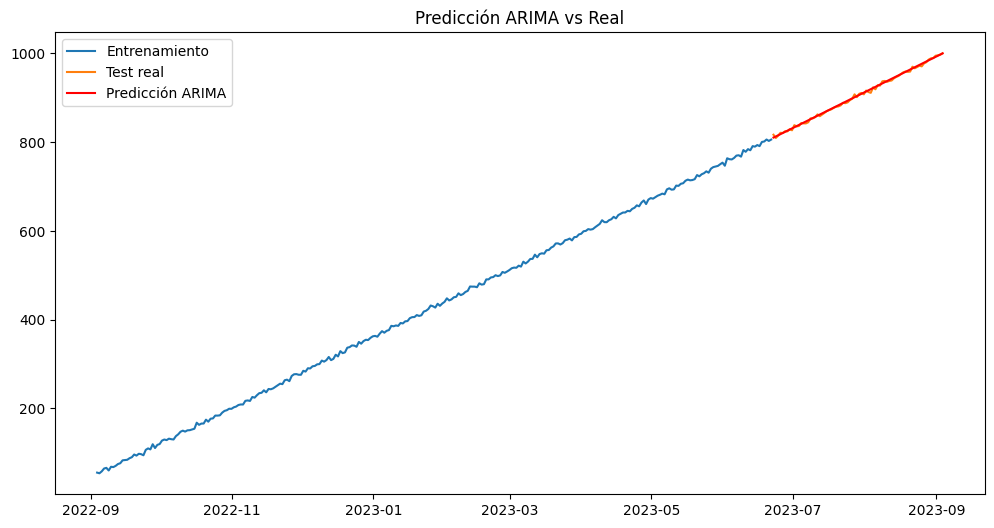

In [54]:
# Separar en entrenamiento y test (por ejemplo, 80% train, 20% test)
train_size = int(len(df) * 0.8)
train, test = df['sales'][:train_size], df['sales'][train_size:]

# Entrenar el modelo ARIMA con los mejores parámetros encontrados
modelo = ARIMA(train, order=(2,1,2))  # Ajusta (2,1,2) si encontraste otros mejores
resultado = modelo.fit()

# Predecir sobre el conjunto de test
predicciones = resultado.forecast(steps=len(test))

# Comparar predicciones vs valores reales
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Test real')
plt.plot(test.index, predicciones, label='Predicción ARIMA', color='red')
plt.legend()
plt.title('Predicción ARIMA vs Real')
plt.show()


La conclusión del último código es que permite evaluar el desempeño del modelo ARIMA al comparar las predicciones generadas para el conjunto de test con los valores reales de ventas. Al graficar ambas series (real y predicha), puedes visualizar si el modelo logra seguir la tendencia y las variaciones de los datos reales. Si las líneas de predicción y test son similares, el modelo es adecuado; si hay mucha diferencia, el modelo necesita ajustes en sus parámetros o en el preprocesamiento de los datos.

## <span style="color: green;"> Guarda el Modelo .</span>

In [55]:
with open('../models/arima_sales.pkl', 'wb') as f:
    pickle.dump(resultado, f)
print("Modelo ARIMA guardado en ../models/arima_sales.pkl")


Modelo ARIMA guardado en ../models/arima_sales.pkl
